# FakeLens 360 — FakeNewsNet : audit, modèles et préparation XLM-R

Ce notebook utilise les quatre fichiers CSV GossipCop et PolitiFact. Les textes disponibles sont les **titres**, accompagnés de métadonnées : URL, domaine, sous-dataset et volume de tweets.

Livrables : audit, suppression des doublons/fuites, baseline TF-IDF, modèle hybride, analyse d'erreurs, confiance, test de robustesse sur des domaines inconnus et export XLM-R.

In [1]:
!pip install -q joblib scikit-learn pandas matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
from urllib.parse import urlparse
import sys, zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/FakeNewsDetection')
sys.path.insert(0, str(PROJECT_ROOT))

from src.fakelens_common import (
    locate_file, normalize_text, basic_audit, remove_conflicting_duplicates,
    stratified_row_split, group_robust_split, split_overlap_report,
    make_text_svm, make_text_probability_model, make_hybrid_model,
    evaluate_model, save_confusion, confidence_table, save_errors,
    top_linear_features,
)

RAW_ZIP = locate_file(PROJECT_ROOT, 'FakeNewsNet.zip')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'fakenewsnet'
MODELS_DIR = PROJECT_ROOT / 'models' / 'fakenewsnet'
for path in [PROCESSED_DIR, RESULTS_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Archive :', RAW_ZIP)

Archive : /content/drive/MyDrive/FakeNewsDetection/FakeNewsNet.zip


## 1. Chargement des quatre fichiers

In [4]:
frames = []
with zipfile.ZipFile(RAW_ZIP) as archive:
    for member in archive.namelist():
        if not member.lower().endswith('.csv'):
            continue
        filename = Path(member).name.lower()
        source_dataset = 'gossipcop' if 'gossipcop' in filename else 'politifact'
        label = 'FAKE' if '_fake' in filename else 'REAL'
        with archive.open(member) as file_obj:
            part = pd.read_csv(file_obj)
        part['source_dataset'] = source_dataset
        part['label_binary'] = label
        part['label_original'] = label.lower()
        frames.append(part)

df = pd.concat(frames, ignore_index=True)
print(df.shape)
display(pd.crosstab(df['source_dataset'], df['label_binary']))

(23196, 7)


label_binary,FAKE,REAL
source_dataset,,
gossipcop,5323,16817
politifact,432,624


## 2. Nettoyage et création des métadonnées

In [5]:
def extract_domain(url):
    if pd.isna(url) or not str(url).strip():
        return 'unknown'
    raw = str(url).strip()
    if not raw.startswith(('http://', 'https://')):
        raw = 'http://' + raw
    try:
        domain = urlparse(raw).netloc.lower()
        return domain.removeprefix('www.') or 'unknown'
    except Exception:
        return 'unknown'

def count_tweets(value):
    if pd.isna(value) or not str(value).strip():
        return 0
    return len(str(value).split('	'))

df['title'] = df['title'].fillna('').astype(str).str.strip()
df['text'] = df['title']
df['text_norm'] = df['text'].map(normalize_text)
df['domain'] = df['news_url'].map(extract_domain)
df['tweet_count'] = df['tweet_ids'].map(count_tweets)
df['title_len'] = df['title'].str.len()
df['word_count'] = df['title'].str.split().str.len()
df['has_url'] = df['news_url'].notna().astype(int)
df = df[df['text_norm'].str.len() >= 5].reset_index(drop=True)

display(basic_audit(df, 'text', 'label_binary'))
display(df.isna().mean().mul(100).sort_values(ascending=False).to_frame('manquants_%').head(10))

,lignes,textes_vides,doublons_texte,labels,mots_moyens,caracteres_moyens
0,23196,0,1478,2,11.16,68.3


,manquants_%
tweet_ids,6.470943
news_url,1.422659
id,0.000000
title,0.000000
source_dataset,0.000000
label_binary,0.000000
label_original,0.000000
text,0.000000
text_norm,0.000000
domain,0.000000


## 3. Doublons, contradictions et fuites

In [6]:
clean_df, duplicate_report = remove_conflicting_duplicates(
    df, text_key='text_norm', label_col='label_binary'
)
print(duplicate_report)
pd.DataFrame([duplicate_report]).to_csv(RESULTS_DIR / 'fakenewsnet_duplicate_report.csv', index=False)

# Stratification conjointe pour conserver les proportions GossipCop/PolitiFact et FAKE/REAL.
clean_df['stratum'] = clean_df['source_dataset'] + '_' + clean_df['label_binary']
split_df = stratified_row_split(clean_df, stratify_col='stratum')

overlap = split_overlap_report(split_df, text_key='text_norm', group_col='domain')
display(overlap)
overlap.to_csv(RESULTS_DIR / 'fakenewsnet_leakage_audit.csv', index=False)

{'textes_avec_labels_contradictoires': 125, 'lignes_supprimees_total': 1603}


,comparaison,textes_communs,groupes_communs
0,train ↔ valid,0,510
1,train ↔ test,0,512
2,valid ↔ test,0,352


## 4. Visualisations d’audit

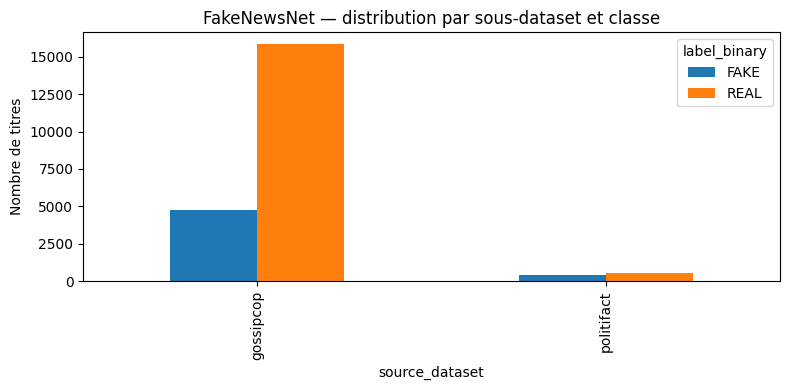

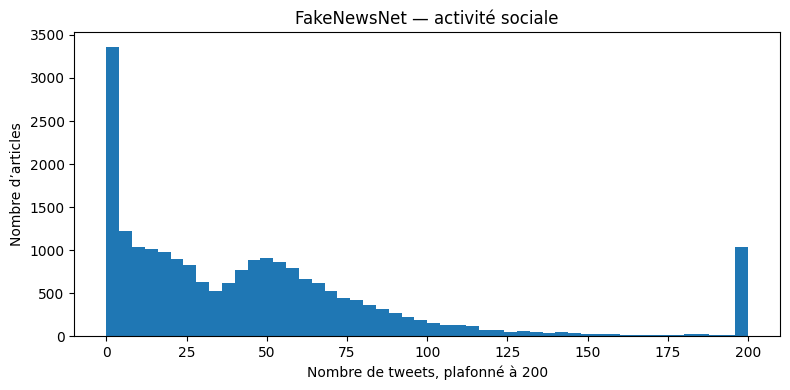

In [7]:
counts = split_df.groupby(['source_dataset', 'label_binary']).size().unstack(fill_value=0)
counts.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Nombre de titres')
plt.title('FakeNewsNet — distribution par sous-dataset et classe')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fakenewsnet_distribution.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(split_df['tweet_count'].clip(upper=200), bins=50)
plt.xlabel('Nombre de tweets, plafonné à 200')
plt.ylabel('Nombre d’articles')
plt.title('FakeNewsNet — activité sociale')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fakenewsnet_tweet_distribution.png', dpi=160)
plt.show()

## 5. Ensembles de travail

In [8]:
train = split_df[split_df.split == 'train'].reset_index(drop=True)
valid = split_df[split_df.split == 'valid'].reset_index(drop=True)
test = split_df[split_df.split == 'test'].reset_index(drop=True)
print({name: len(part) for name, part in [('train', train), ('valid', valid), ('test', test)]})
print(pd.crosstab(split_df['split'], split_df['label_binary']))

{'train': 15115, 'valid': 3239, 'test': 3239}
label_binary  FAKE   REAL
split                    
test           780   2459
train         3638  11477
valid          779   2460


## 6. Baseline TF-IDF mots + caractères

modele             TF-IDF + LinearSVC
split                           valid
accuracy                     0.825255
precision_macro              0.760707
recall_macro                 0.771801
f1_macro                     0.765894
f1_weighted                  0.827074
dtype: object
              precision    recall  f1-score   support

        FAKE     0.6285    0.6688    0.6480       779
        REAL     0.8929    0.8748    0.8838      2460

    accuracy                         0.8253      3239
   macro avg     0.7607    0.7718    0.7659      3239
weighted avg     0.8293    0.8253    0.8271      3239

modele             TF-IDF + LinearSVC
split                            test
accuracy                     0.823402
precision_macro              0.758413
recall_macro                 0.764203
f1_macro                     0.761209
f1_weighted                  0.824381
dtype: object
              precision    recall  f1-score   support

        FAKE     0.6290    0.6500    0.6393       780
    

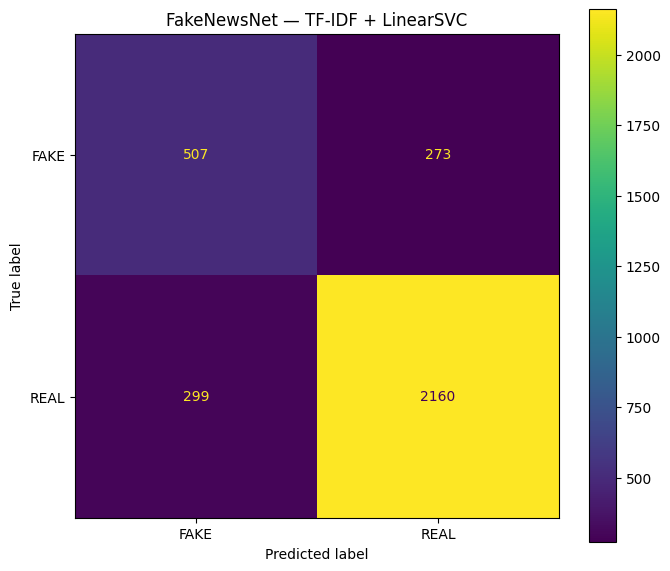

['/content/drive/MyDrive/FakeNewsDetection/models/fakenewsnet/fakenewsnet_text_svm.joblib']

In [9]:
text_svm = make_text_svm(language='en')
text_svm.fit(train['text'], train['label_binary'])

results = []
valid_pred, result = evaluate_model(text_svm, valid['text'], valid['label_binary'], 'TF-IDF + LinearSVC', 'valid')
results.append(result)
test_pred, result = evaluate_model(text_svm, test['text'], test['label_binary'], 'TF-IDF + LinearSVC', 'test')
results.append(result)

save_confusion(
    test['label_binary'], test_pred, ['FAKE', 'REAL'],
    RESULTS_DIR / 'fakenewsnet_confusion_text_svm.png',
    'FakeNewsNet — TF-IDF + LinearSVC'
)
joblib.dump(text_svm, MODELS_DIR / 'fakenewsnet_text_svm.joblib')

## 7. Modèle texte + métadonnées

In [10]:
hybrid = make_hybrid_model(
    text_col='text',
    categorical_cols=['source_dataset', 'domain'],
    numeric_cols=['tweet_count', 'title_len', 'word_count', 'has_url'],
    language='en',
)
hybrid.fit(train, train['label_binary'])

hybrid_valid_pred, result = evaluate_model(hybrid, valid, valid['label_binary'], 'Texte + métadonnées', 'valid')
results.append(result)
hybrid_test_pred, result = evaluate_model(hybrid, test, test['label_binary'], 'Texte + métadonnées', 'test')
results.append(result)
joblib.dump(hybrid, MODELS_DIR / 'fakenewsnet_hybrid.joblib')

results_df = pd.DataFrame(results).sort_values(['split', 'f1_macro'], ascending=[True, False])
display(results_df)
results_df.to_csv(RESULTS_DIR / 'fakenewsnet_model_comparison.csv', index=False)

modele             Texte + métadonnées
split                            valid
accuracy                      0.794072
precision_macro               0.747765
recall_macro                  0.821448
f1_macro                      0.760673
f1_weighted                   0.807073
dtype: object
              precision    recall  f1-score   support

        FAKE     0.5448    0.8742    0.6713       779
        REAL     0.9507    0.7687    0.8501      2460

    accuracy                         0.7941      3239
   macro avg     0.7478    0.8214    0.7607      3239
weighted avg     0.8531    0.7941    0.8071      3239

modele             Texte + métadonnées
split                             test
accuracy                      0.786354
precision_macro               0.740679
recall_macro                  0.812897
f1_macro                      0.752429
f1_weighted                   0.799935
dtype: object
              precision    recall  f1-score   support

        FAKE     0.5349    0.8641    0.6608 

,modele,split,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
1,TF-IDF + LinearSVC,test,0.823402,0.758413,0.764203,0.761209,0.824381
3,Texte + métadonnées,test,0.786354,0.740679,0.812897,0.752429,0.799935
0,TF-IDF + LinearSVC,valid,0.825255,0.760707,0.771801,0.765894,0.827074
2,Texte + métadonnées,valid,0.794072,0.747765,0.821448,0.760673,0.807073


## 8. Confiance et abstention

,seuil,couverture,n_predictions,accuracy,f1_macro
0,0.5,1.000000,3239,0.818462,0.766234
1,0.6,0.839765,2720,0.861765,0.815867
2,0.7,0.639086,2070,0.902899,0.868650
3,0.8,0.414017,1341,0.937360,0.918659
4,0.9,0.152207,493,0.955375,0.951521


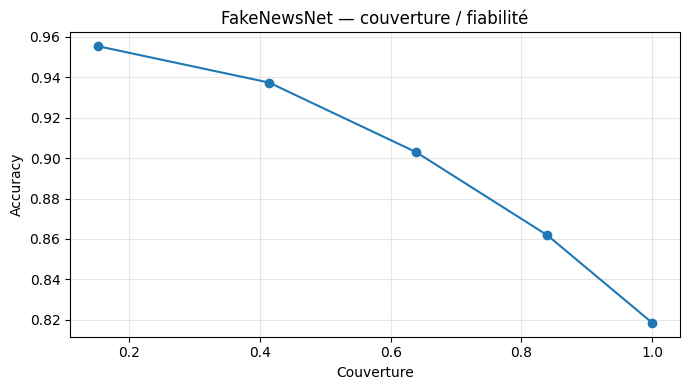

['/content/drive/MyDrive/FakeNewsDetection/models/fakenewsnet/fakenewsnet_confidence_model.joblib']

In [11]:
confidence_model = make_text_probability_model(language='en')
confidence_model.fit(train['text'], train['label_binary'])
proba = confidence_model.predict_proba(test['text'])
pred = confidence_model.classes_[np.argmax(proba, axis=1)]
confidence = proba.max(axis=1)

abstention = confidence_table(test['label_binary'], pred, proba)
display(abstention)
abstention.to_csv(RESULTS_DIR / 'fakenewsnet_confidence_abstention.csv', index=False)

plt.figure(figsize=(7, 4))
plt.plot(abstention['couverture'], abstention['accuracy'], marker='o')
plt.xlabel('Couverture')
plt.ylabel('Accuracy')
plt.title('FakeNewsNet — couverture / fiabilité')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fakenewsnet_coverage_accuracy.png', dpi=160)
plt.show()
joblib.dump(confidence_model, MODELS_DIR / 'fakenewsnet_confidence_model.joblib')

## 9. Analyse des erreurs et mots importants

In [12]:
errors = save_errors(
    test, test['label_binary'], pred, confidence,
    columns=['id', 'source_dataset', 'domain', 'title', 'tweet_count'],
    path=RESULTS_DIR / 'fakenewsnet_top_errors.csv',
)
display(errors.head(20))

features = top_linear_features(text_svm, top_n=30)
display(features)
features.to_csv(RESULTS_DIR / 'fakenewsnet_top_features.csv', index=False)

,id,source_dataset,domain,title,tweet_count,vrai,prediction,confiance
226,gossipcop-863870,gossipcop,usatoday.com,Brad Pitt and Angelina Jolie: Could they go to...,31,REAL,FAKE,0.973187
829,gossipcop-875208,gossipcop,usmagazine.com,Brad Pitt and Angelina Jolie: A Timeline of Th...,19,REAL,FAKE,0.971450
2164,gossipcop-3173304545,gossipcop,abc.go.com,Watch Bachelor in Paradise TV Show,990,FAKE,REAL,0.970712
2786,gossipcop-1509983640,gossipcop,eonline.com,James Corden Apologizes for Harvey Weinstein J...,77,FAKE,REAL,0.967519
2970,gossipcop-915950,gossipcop,vogue.com,Is Selena Gomez Shopping Justin Bieber’s Closet?,39,REAL,FAKE,0.955685
296,gossipcop-914281,gossipcop,hindustantimes.com,The internet has realised that both Jennifer A...,70,REAL,FAKE,0.948595
2188,gossipcop-941589,gossipcop,instylemag.com.au,Kristen Stewart And Robert Pattinson’s Surpris...,15,REAL,FAKE,0.946918
357,gossipcop-938852,gossipcop,article.wn.com,Brad Pitt and Angelina Jolie Still ''at Odds''...,54,REAL,FAKE,0.946749
301,gossipcop-9024002184,gossipcop,glamour.com,Chrissy Teigen Opens Up for the First Time Abo...,134,FAKE,REAL,0.944142
1551,gossipcop-875665,gossipcop,hurricanecategory.com,Gwen Stefani IMDb Imdb News,23,REAL,FAKE,0.938393


,feature,coefficient,direction
0,word__paris jackson,-1.628951,FAKE
1,word__on taylor,-1.586408,FAKE
2,char__ &,-1.515841,FAKE
3,word__celebrities react,-1.498974,FAKE
4,word__breaking,-1.490428,FAKE
5,char__ ’,-1.455715,FAKE
6,word__living together,-1.450006,FAKE
7,word__hart and,-1.393169,FAKE
8,word__pepe,-1.387987,FAKE
9,word__pretty woman,-1.382161,FAKE


## 10. Test de robustesse : domaines jamais vus

Cette expérience est plus sévère : tous les articles d'un domaine restent dans le même split. Elle vérifie que le modèle ne mémorise pas simplement les sites.

In [13]:
domain_df = group_robust_split(clean_df, group_col='domain', label_col='label_binary')
domain_train = domain_df[domain_df.split == 'train']
domain_test = domain_df[domain_df.split == 'test']

robust_model = make_text_svm(language='en')
robust_model.fit(domain_train['text'], domain_train['label_binary'])
robust_pred, robust_result = evaluate_model(
    robust_model, domain_test['text'], domain_test['label_binary'],
    'TF-IDF — domaines inconnus', 'domain_test'
)
pd.DataFrame([robust_result]).to_csv(RESULTS_DIR / 'fakenewsnet_domain_robustness.csv', index=False)
print('Domaines communs train/test :', len(set(domain_train.domain) & set(domain_test.domain)))

modele             TF-IDF — domaines inconnus
split                             domain_test
accuracy                                  0.8
precision_macro                      0.795677
recall_macro                         0.780319
f1_macro                             0.785828
f1_weighted                           0.79734
dtype: object
              precision    recall  f1-score   support

        FAKE     0.7815    0.6861    0.7307      1147
        REAL     0.8098    0.8745    0.8409      1753

    accuracy                         0.8000      2900
   macro avg     0.7957    0.7803    0.7858      2900
weighted avg     0.7986    0.8000    0.7973      2900

Domaines communs train/test : 0


## 11. Export standardisé pour XLM-RoBERTa

In [14]:
for split_name in ['train', 'valid', 'test']:
    part = split_df[split_df.split == split_name].copy()
    standardized = pd.DataFrame({
        'text': part['text'],
        'label_original': part['label_original'],
        'label_3class': part['label_binary'],
        'label_binary': part['label_binary'],
        'dataset': 'FakeNewsNet',
        'language': 'en',
        'split': split_name,
        'source': part['source_dataset'],
        'domain': part['domain'],
        'tweet_count': part['tweet_count'],
    })
    standardized.to_csv(PROCESSED_DIR / f'fakenewsnet_{split_name}_standardized.csv', index=False)

print('Exports créés dans :', PROCESSED_DIR)
print('Étape suivante : exécuter le notebook XLM-R multilingue.')

Exports créés dans : /content/drive/MyDrive/FakeNewsDetection/data/processed
Étape suivante : exécuter le notebook XLM-R multilingue.
